# Notebook 17 — Fine-tuning patch experiment (viva item 6)

**Examiner's comment (31 Jul 2026, item 6):**
> *Fine-tuning Analysis: the fine-tuned model still exhibits negative metrics; either a patch on
> experiments or a detailed justification for each of these is required.*

**What was wrong.** In Notebook 10 the mitigation experiment had exactly one adaptation arm —
fine-tune every weight for 10 epochs at lr = 2e-4 on a small recent slice — and it made the long
horizons *worse* (ΔR² = −0.85 at h = 21 d, −1.11 at h = 28 d). One failed arm is not evidence that
adaptation cannot work; it is evidence that *that* arm did not work.

**What this notebook does.** It replaces the single arm with a ladder of six adaptation strategies,
each targeting a different candidate cause of the failure, all trained on the same 2023 calibration
year and all scored on the same strictly-later 2024–2025 evaluation window:

| Arm | Strategy | The cause it tests |
|-----|----------|--------------------|
| **A0** | Frozen 2013–2022 model (no adaptation) | reference point |
| **A1** | Fine-tune the Dense head only, encoder + attention frozen | catastrophic forgetting of the temporal encoder |
| **A2** | Fine-tune all weights, lr = 1e-4, **validation-based early stopping** on a held-out 2023 slice | the original arm had no validation set and could not stop |
| **A3** | Frozen weights, **target scaler re-fitted on 2023** | output-range mismatch: the sigmoid head was calibrated to a 256 cases/day regime, the new regime peaks near 73 |
| **A4** | Frozen weights, **affine recalibration** `ŷ' = a + b·ŷ` fitted on 2023 | pure level/scale bias, no retraining at all |
| **A5** | **Retrain from scratch** on 2013–2023 (expanding window) | is the problem adaptation, or simply that 2023 must be in the training set? |

Each arm is run over the same 30 seeds and every horizon, and each is tested against A0 with a
paired test, Holm-corrected across the family of comparisons.

**Why negative R² is also *decomposed*, not just reported.** `score()` in `viva_revision_common.py`
splits the mean squared error into a systematic component (bias²) and a dispersion component, and
reports the ratio of predicted to actual standard deviation. If a negative R² is driven by bias — a
constant level offset — that is a calibration failure and A3/A4 should fix it. If it is driven by
dispersion, the model genuinely has no signal at that horizon and no amount of recalibration will
help. That distinction is the "detailed justification" the examiner asked for, stated as a number
rather than as a narrative.

**Runtime.** ≈ 2 hours on a GPU machine (5 horizons × 30 seeds; A1–A4 reuse A0's trained weights,
only A5 trains a second model per seed).

In [1]:
import os, sys, json, time, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

sys.path.insert(0, os.getcwd())
from viva_revision_common import (
    SEEDS, N_SEEDS, HORIZONS, SEQ_LEN, ALPHA,
    build_features, feature_sets, build_lstm_transformer,
    score, fit_target_scaler, inverse, train_model, predict, release,
    paired_test, holm, decide, ci_mean, summarise, boxplot_mean_median, LEGEND_NOTE,
)
from sklearn.preprocessing import RobustScaler

os.makedirs('metrics', exist_ok=True)
os.makedirs('plots', exist_ok=True)
plt.rcParams.update({'font.size': 9, 'figure.dpi': 130})

print('TensorFlow devices:', __import__('tensorflow').config.list_physical_devices())

viva_revision_common loaded — 30 seeds 42..245, horizons [1, 7, 14, 21, 28]
TensorFlow devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Data — three strictly ordered periods

The combined 2013–2025 series is used so that feature lags cross the 2022/2023 boundary correctly
(building features on the 2023–2025 file in isolation silently drops the first 28 days and breaks
every lag that reaches back into 2022).

| Period | Dates | Role |
|--------|-------|------|
| **TRAIN** | 2013-01-01 → 2022-12-31 | fits the base model, all arms |
| **CALIB** | 2023-01-01 → 2023-12-31 | the only data any arm is allowed to adapt on |
| **EVAL**  | 2024-01-01 → end        | scored; never seen by any arm |

Because every arm adapts on CALIB and is scored on EVAL, the comparison between arms is fair and
no arm can gain from having seen the evaluation period.

In [2]:
COMBINED_CSV = 'singapore_dengue_weather_2013_2025_combined.csv'

df = build_features(pd.read_csv(COMBINED_CSV))
rf_features, dl_seq_features, dl_feat_features = feature_sets(df)

TRAIN_END = pd.Timestamp('2022-12-31')
CALIB_END = pd.Timestamp('2023-12-31')

seq_scaler  = RobustScaler().fit(df.loc[df.date <= TRAIN_END, dl_seq_features].values)
feat_scaler = RobustScaler().fit(df.loc[df.date <= TRAIN_END, dl_feat_features].values)

X_seq  = seq_scaler.transform(df[dl_seq_features].values)
X_feat = feat_scaler.transform(df[dl_feat_features].values)
y_raw  = df['dengue_cases'].values
dates  = df['date'].values


def windows(h):
    '''Sliding windows over the whole series, tagged by the DATE OF THE TARGET.

    Returns (Xs, Xf, y, target_dates). Splitting on the target date is what
    guarantees no window used for evaluation has its label inside CALIB.'''
    Xs, Xf, Y, D = [], [], [], []
    for i in range(SEQ_LEN, len(X_seq) - h):
        Xs.append(X_seq[i - SEQ_LEN:i]); Xf.append(X_feat[i])
        Y.append(y_raw[i + h]);          D.append(dates[i + h])
    return np.array(Xs), np.array(Xf), np.array(Y), pd.to_datetime(np.array(D))


print(f'Records after feature engineering : {len(df):,}')
print(f'Date range                        : {df.date.min().date()} -> {df.date.max().date()}')
print(f'Sequence features / branch features: {len(dl_seq_features)} / {len(dl_feat_features)}')

for lab, m in [('TRAIN 2013-2022', df.date <= TRAIN_END),
               ('CALIB 2023',      (df.date > TRAIN_END) & (df.date <= CALIB_END)),
               ('EVAL  2024-2025', df.date > CALIB_END)]:
    v = y_raw[m.values]
    print(f'  {lab:<16} n={len(v):>5}  mean={v.mean():7.2f}  sd={v.std():6.2f}  max={v.max():7.1f}')

Records after feature engineering : 4,707
Date range                        : 2013-02-11 -> 2025-12-31
Sequence features / branch features: 60 / 44
  TRAIN 2013-2022  n= 3611  mean=  43.76  sd= 43.52  max=  256.0
  CALIB 2023       n=  365  mean=  27.35  sd=  8.90  max=   48.6
  EVAL  2024-2025  n=  731  mean=  24.03  sd= 17.91  max=   73.4


## 2. Diagnosis — how large is the regime shift, and what does it do to a sigmoid head?

Before patching anything, quantify the shift. The ILT's output layer is a sigmoid mapped onto the
training target range through a `MinMaxScaler`. If the training regime peaks at 256 cases/day and
the evaluation regime peaks near 73, then *even a perfectly ranked forecast* is pushed onto the
wrong level, and R² — which is measured against the evaluation period's own variance — collapses.
This cell measures that, so the later arms can be judged against a stated mechanism.

In [3]:
tr, ca, ev = (df.date <= TRAIN_END).values, ((df.date > TRAIN_END) & (df.date <= CALIB_END)).values, (df.date > CALIB_END).values
rows = []
for lab, m in [('TRAIN 2013-2022', tr), ('CALIB 2023', ca), ('EVAL 2024-2025', ev)]:
    v = y_raw[m]
    rows.append(dict(period=lab, n=len(v), mean=v.mean(), median=np.median(v), sd=v.std(),
                     p95=np.percentile(v, 95), max=v.max(), cv=v.std() / v.mean()))
shift = pd.DataFrame(rows).round(3)
display(shift)

tr_v, ev_v = y_raw[tr], y_raw[ev]
ks = stats.ks_2samp(tr_v, ev_v)
print(f'\nKolmogorov-Smirnov, TRAIN vs EVAL target distribution: D={ks.statistic:.4f}, p={ks.pvalue:.3e}')
print(f'  -> H0: the two periods are draws from the same distribution.  {decide(ks.pvalue)}')
print(f'\nScale mismatch the sigmoid head has to absorb:')
print(f'  training target max      : {tr_v.max():.1f} cases/day')
print(f'  evaluation target max    : {ev_v.max():.1f} cases/day')
print(f'  ratio                    : {tr_v.max()/ev_v.max():.2f}x')
print(f'  evaluation variance      : {ev_v.var():.1f}   (R2 is measured against THIS)')
print(f'  a constant level error of {np.sqrt(ev_v.var()):.1f} cases/day alone drives R2 to 0.')
shift.to_csv('metrics/nb17_regime_shift_diagnosis.csv', index=False)

,period,n,mean,median,sd,p95,max,cv
0,TRAIN 2013-2022,3611,43.764,32.286,43.520,134.000,256.000,0.994
1,CALIB 2023,365,27.347,27.429,8.901,43.143,48.571,0.325
2,EVAL 2024-2025,731,24.026,16.000,17.910,59.143,73.429,0.745



Kolmogorov-Smirnov, TRAIN vs EVAL target distribution: D=0.2986, p=2.006e-48
  -> H0: the two periods are draws from the same distribution.  Reject H0

Scale mismatch the sigmoid head has to absorb:
  training target max      : 256.0 cases/day
  evaluation target max    : 73.4 cases/day
  ratio                    : 3.49x
  evaluation variance      : 320.8   (R2 is measured against THIS)
  a constant level error of 17.9 cases/day alone drives R2 to 0.


## 3. The six adaptation arms

All arms share one base model per (horizon, seed), trained on TRAIN only. A1–A4 start from that
model, so their only difference from A0 is the adaptation step itself.

In [4]:
FT_EPOCHS   = 40      # generous; early stopping decides when to stop
FT_PATIENCE = 8


def clone_weights(model):
    return [w.copy() for w in model.get_weights()]


def run_arm(arm, base, base_scaler, packs, seed):
    '''Return predictions on EVAL for one arm. `packs` holds the pre-built splits.'''
    (Xs_ca, Xf_ca, y_ca), (Xs_ev, Xf_ev, y_ev) = packs['calib'], packs['eval']
    import tensorflow as tf
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping

    if arm == 'A0_frozen':
        return predict(base, Xs_ev, Xf_ev, base_scaler)

    if arm == 'A3_rescale':
        # Same weights, but the sigmoid output is mapped through a scaler fitted
        # on the CALIB year instead of on 2013-2022.
        new_scaler = fit_target_scaler(y_ca, clip_pct=None)
        return inverse(new_scaler, base.predict([Xs_ev, Xf_ev], verbose=0).ravel())

    if arm == 'A4_recalibrate':
        # No retraining at all: fit y ~ a + b*yhat on CALIB, apply to EVAL.
        p_ca = predict(base, Xs_ca, Xf_ca, base_scaler)
        lr = LinearRegression().fit(p_ca.reshape(-1, 1), y_ca)
        p_ev = predict(base, Xs_ev, Xf_ev, base_scaler)
        return np.maximum(lr.predict(p_ev.reshape(-1, 1)), 0)

    if arm in ('A1_head_only', 'A2_full_earlystop'):
        w0 = clone_weights(base)
        base.set_weights(w0)
        y_ca_sc = base_scaler.transform(y_ca.reshape(-1, 1)).ravel()
        vs = max(int(len(Xs_ca) * 0.2), 30)          # tail of 2023 as validation
        if arm == 'A1_head_only':
            for layer in base.layers:
                layer.trainable = ('dense' in layer.name.lower())
            lr_ft = 5e-4
        else:
            for layer in base.layers:
                layer.trainable = True
            lr_ft = 1e-4
        base.compile(optimizer=Adam(learning_rate=lr_ft, clipnorm=1.0), loss='mse')
        base.fit([Xs_ca[:-vs], Xf_ca[:-vs]], y_ca_sc[:-vs],
                 validation_data=([Xs_ca[-vs:], Xf_ca[-vs:]], y_ca_sc[-vs:]),
                 epochs=FT_EPOCHS, batch_size=16, verbose=0,
                 callbacks=[EarlyStopping('val_loss', patience=FT_PATIENCE,
                                          restore_best_weights=True, verbose=0)])
        p = predict(base, Xs_ev, Xf_ev, base_scaler)
        base.set_weights(w0)                          # restore for the next arm
        for layer in base.layers:
            layer.trainable = True
        base.compile(optimizer=Adam(learning_rate=1e-3, clipnorm=1.0), loss='mse')
        return p

    raise ValueError(arm)


ARMS = ['A0_frozen', 'A1_head_only', 'A2_full_earlystop',
        'A3_rescale', 'A4_recalibrate', 'A5_retrain_expanding']
ARM_LABEL = {
    'A0_frozen':            'A0  frozen (no adaptation)',
    'A1_head_only':         'A1  fine-tune head only',
    'A2_full_earlystop':    'A2  fine-tune all + early stop',
    'A3_rescale':           'A3  re-fit target scaler on 2023',
    'A4_recalibrate':       'A4  affine recalibration on 2023',
    'A5_retrain_expanding': 'A5  retrain on 2013-2023',
}
print('\n'.join(f'{k:<24} {v}' for k, v in ARM_LABEL.items()))

A0_frozen                A0  frozen (no adaptation)
A1_head_only             A1  fine-tune head only
A2_full_earlystop        A2  fine-tune all + early stop
A3_rescale               A3  re-fit target scaler on 2023
A4_recalibrate           A4  affine recalibration on 2023
A5_retrain_expanding     A5  retrain on 2013-2023


In [5]:
t_start = time.time()
records = []          # one row per (horizon, arm, seed)
pred_store = {}       # ensemble predictions for the figures

for h in HORIZONS:
    Xs, Xf, Y, D = windows(h)
    m_tr = D <= TRAIN_END
    m_ca = (D > TRAIN_END) & (D <= CALIB_END)
    m_ev = D > CALIB_END
    packs = {'train': (Xs[m_tr], Xf[m_tr], Y[m_tr]),
             'calib': (Xs[m_ca], Xf[m_ca], Y[m_ca]),
             'eval':  (Xs[m_ev], Xf[m_ev], Y[m_ev])}
    Xs_tr, Xf_tr, y_tr = packs['train']
    Xs_ca, Xf_ca, y_ca = packs['calib']
    Xs_ev, Xf_ev, y_ev = packs['eval']

    # expanding-window training set for A5 = TRAIN + CALIB
    Xs_ex = np.concatenate([Xs_tr, Xs_ca]); Xf_ex = np.concatenate([Xf_tr, Xf_ca])
    y_ex  = np.concatenate([y_tr, y_ca])

    base_scaler = fit_target_scaler(y_tr, clip_pct=95)
    exp_scaler  = fit_target_scaler(y_ex, clip_pct=95)
    y_tr_sc = base_scaler.transform(np.clip(y_tr, 0, np.percentile(y_tr, 95)).reshape(-1, 1)).ravel()
    y_ex_sc = exp_scaler.transform(np.clip(y_ex, 0, np.percentile(y_ex, 95)).reshape(-1, 1)).ravel()

    print(f'\n{"="*78}\n  h = {h} d   train={len(y_tr)}  calib={len(y_ca)}  eval={len(y_ev)}\n{"="*78}')
    acc = {a: [] for a in ARMS}

    for si, seed in enumerate(SEEDS):
        base = train_model(seed, build_lstm_transformer, Xs_tr, Xf_tr, y_tr_sc)
        for arm in ARMS[:-1]:
            p = run_arm(arm, base, base_scaler, packs, seed)
            acc[arm].append(p)
            records.append(dict(horizon=h, arm=arm, seed=seed, **score(y_ev, p)))
        release(base)

        m5 = train_model(seed, build_lstm_transformer, Xs_ex, Xf_ex, y_ex_sc)
        p5 = predict(m5, Xs_ev, Xf_ev, exp_scaler)
        acc['A5_retrain_expanding'].append(p5)
        records.append(dict(horizon=h, arm='A5_retrain_expanding', seed=seed, **score(y_ev, p5)))
        release(m5)

        if (si + 1) % 5 == 0:
            el = time.time() - t_start
            print(f'    seed {si+1:>2}/{N_SEEDS}   elapsed {el/60:5.1f} min')

    pred_store[h] = {a: np.mean(acc[a], axis=0) for a in ARMS}
    pred_store[h]['actual'] = y_ev
    for a in ARMS:
        r2s = [r['r2'] for r in records if r['horizon'] == h and r['arm'] == a]
        print(f'    {ARM_LABEL[a]:<34} mean R2 = {np.mean(r2s):+.4f}   median = {np.median(r2s):+.4f}')

res = pd.DataFrame(records)
res.to_csv('metrics/nb17_finetune_arms_per_seed.csv', index=False)
with open('metrics/nb17_finetune_predictions.pkl', 'wb') as f:
    pickle.dump(pred_store, f)
print(f'\nTotal runtime {(time.time()-t_start)/60:.1f} min · {len(res)} rows saved')


  h = 1 d   train=3582  calib=365  eval=731

    seed  5/30   elapsed   4.2 min
    seed 10/30   elapsed   8.2 min
    seed 15/30   elapsed  12.5 min
    seed 20/30   elapsed  17.0 min
    seed 25/30   elapsed  21.6 min
    seed 30/30   elapsed  26.2 min
    A0  frozen (no adaptation)         mean R2 = +0.6125   median = +0.6210
    A1  fine-tune head only            mean R2 = +0.6596   median = +0.6804
    A2  fine-tune all + early stop     mean R2 = +0.7082   median = +0.6980
    A3  re-fit target scaler on 2023   mean R2 = +0.4029   median = +0.3957
    A4  affine recalibration on 2023   mean R2 = +0.6901   median = +0.7009
    A5  retrain on 2013-2023           mean R2 = +0.5133   median = +0.5252

  h = 7 d   train=3576  calib=365  eval=731
    seed  5/30   elapsed  30.3 min
    seed 10/30   elapsed  34.6 min
    seed 15/30   elapsed  38.7 min
    seed 20/30   elapsed  43.1 min
    seed 25/30   elapsed  47.7 min
    seed 30/30   elapsed  52.4 min
    A0  frozen (no adaptation)   

## 4. Did any arm restore positive skill?

Two questions are asked separately, because they are separate claims:

* **Q1 — absolute:** is the arm's out-of-sample R² greater than zero?
  `H0: mean R² ≤ 0` vs `Ha: mean R² > 0`, one-sample t over the 30 seeds.
* **Q2 — relative:** does the arm beat the un-adapted A0 baseline?
  `H0: mean(R²_arm − R²_A0) = 0` vs `Ha: > 0`, paired by seed.

Holm correction is applied across the whole family of arm × horizon comparisons, so the
"significant" label survives the multiplicity the examiner would otherwise object to.

In [6]:
summary = []
for h in HORIZONS:
    base_r2 = res[(res.horizon == h) & (res.arm == 'A0_frozen')].sort_values('seed')['r2'].values
    for a in ARMS:
        v = res[(res.horizon == h) & (res.arm == a)].sort_values('seed')
        r2 = v['r2'].values
        t, p2 = stats.ttest_1samp(r2, 0.0)
        p_abs = p2 / 2 if t > 0 else 1 - p2 / 2
        if a == 'A0_frozen':
            p_rel, d_rel = np.nan, 0.0
        else:
            d = r2 - base_r2
            t2, p22 = stats.ttest_rel(r2, base_r2)
            p_rel = p22 / 2 if t2 > 0 else 1 - p22 / 2
            d_rel = d.mean()
        lo, hi = ci_mean(r2)
        summary.append(dict(
            horizon=f'h={h}d', arm=a, label=ARM_LABEL[a],
            r2_mean=r2.mean(), r2_median=np.median(r2), r2_sd=r2.std(ddof=1),
            r2_ci_lo=lo, r2_ci_hi=hi,
            rmse_mean=v['rmse'].mean(), mae_mean=v['mae'].mean(),
            bias_mean=v['bias'].mean(), bias_sq_share=v['bias_sq_share'].mean(),
            scale_ratio=v['scale_ratio'].mean(),
            p_r2_gt_0=p_abs, delta_r2_vs_A0=d_rel, p_vs_A0=p_rel))

S = pd.DataFrame(summary)
S['p_r2_gt_0_holm'] = holm(S['p_r2_gt_0'].fillna(1.0))
mask = S['p_vs_A0'].notna()
S.loc[mask, 'p_vs_A0_holm'] = holm(S.loc[mask, 'p_vs_A0'])
S['decision_r2_gt_0'] = [decide(p) for p in S['p_r2_gt_0_holm']]
S['decision_vs_A0'] = [decide(p) if pd.notna(p) else '(reference arm)' for p in S['p_vs_A0_holm']]
S.to_csv('metrics/nb17_finetune_arm_tests.csv', index=False)

pd.set_option('display.width', 220, 'display.max_columns', 40)
for h in HORIZONS:
    print(f'\n{"="*118}\n  h = {h} d   —   H0(abs): mean R2 <= 0    H0(rel): mean(R2_arm - R2_A0) = 0\n{"="*118}')
    sub = S[S.horizon == f'h={h}d']
    print(sub[['label', 'r2_mean', 'r2_median', 'r2_ci_lo', 'r2_ci_hi', 'rmse_mean',
               'p_r2_gt_0_holm', 'decision_r2_gt_0', 'delta_r2_vs_A0', 'p_vs_A0_holm',
               'decision_vs_A0']].round(4).to_string(index=False))


  h = 1 d   —   H0(abs): mean R2 <= 0    H0(rel): mean(R2_arm - R2_A0) = 0
                           label  r2_mean  r2_median  r2_ci_lo  r2_ci_hi  rmse_mean  p_r2_gt_0_holm decision_r2_gt_0  delta_r2_vs_A0  p_vs_A0_holm    decision_vs_A0
      A0  frozen (no adaptation)   0.6125     0.6210    0.5724    0.6526    11.0437             0.0        Reject H0          0.0000           NaN   (reference arm)
         A1  fine-tune head only   0.6596     0.6804    0.6182    0.7010    10.3173             0.0        Reject H0          0.0471        0.1896 Fail to reject H0
  A2  fine-tune all + early stop   0.7082     0.6980    0.6805    0.7358     9.5972             0.0        Reject H0          0.0957        0.0000         Reject H0
A3  re-fit target scaler on 2023   0.4029     0.3957    0.3931    0.4128    13.8357             0.0        Reject H0         -0.2095        1.0000 Fail to reject H0
A4  affine recalibration on 2023   0.6901     0.7009    0.6675    0.7127     9.9255             0.0

## 5. If an arm is still negative — why?

For every arm × horizon that still fails, this table reports *what kind* of failure it is:

* **`bias_sq_share`** — the fraction of the mean squared error that is a constant level offset.
  Close to 1 means the forecast has the right shape at the wrong level: a calibration problem,
  fixable in principle. Close to 0 means the error is dispersion: the forecast has no usable signal.
* **`scale_ratio`** — SD(prediction) ÷ SD(actual). Well below 1 means the model has flattened
  towards a constant; a flat forecast cannot beat the mean and *must* score R² ≤ 0.

This is the quantitative form of the "detailed justification for each of these" the examiner asked
for: each remaining negative number is attributed to a measured mechanism rather than described.

In [7]:
neg = S[S.r2_mean <= 0].copy()
if len(neg) == 0:
    print('No arm x horizon combination retains a negative mean R2.')
else:
    neg['diagnosis'] = np.where(
        neg.bias_sq_share > 0.5, 'level/calibration error (bias dominates MSE)',
        np.where(neg.scale_ratio < 0.5, 'forecast collapsed towards a constant (no usable signal)',
                 'dispersion error — genuine loss of predictive signal'))
    print(neg[['horizon', 'label', 'r2_mean', 'bias_mean', 'bias_sq_share',
               'scale_ratio', 'diagnosis']].round(4).to_string(index=False))
    neg.to_csv('metrics/nb17_negative_metric_justification.csv', index=False)

print('\nFor reference — actual vs predicted level, per arm (h = 28 d):')
print(res[res.horizon == 28].groupby('arm')[['actual_mean', 'pred_mean', 'actual_sd', 'pred_sd']]
      .mean().round(3).to_string())

horizon                          label  r2_mean  bias_mean  bias_sq_share  scale_ratio                                            diagnosis
  h=14d     A0  frozen (no adaptation)  -0.0442     3.7205         0.0514       1.4933 dispersion error — genuine loss of predictive signal
  h=14d       A5  retrain on 2013-2023  -0.2526     6.6594         0.1163       1.5751 dispersion error — genuine loss of predictive signal
  h=21d     A0  frozen (no adaptation)  -0.4197     5.0135         0.0604       1.6167 dispersion error — genuine loss of predictive signal
  h=21d       A5  retrain on 2013-2023  -0.6702     7.4586         0.1102       1.6756 dispersion error — genuine loss of predictive signal
  h=28d     A0  frozen (no adaptation)  -0.9956     7.2038         0.0953       1.7411 dispersion error — genuine loss of predictive signal
  h=28d        A1  fine-tune head only  -0.1897     4.6085         0.0674       1.1166 dispersion error — genuine loss of predictive signal
  h=28d A2  fine-tun

## 6. Figures — every box plot shows both the mean and the median (viva item 7)

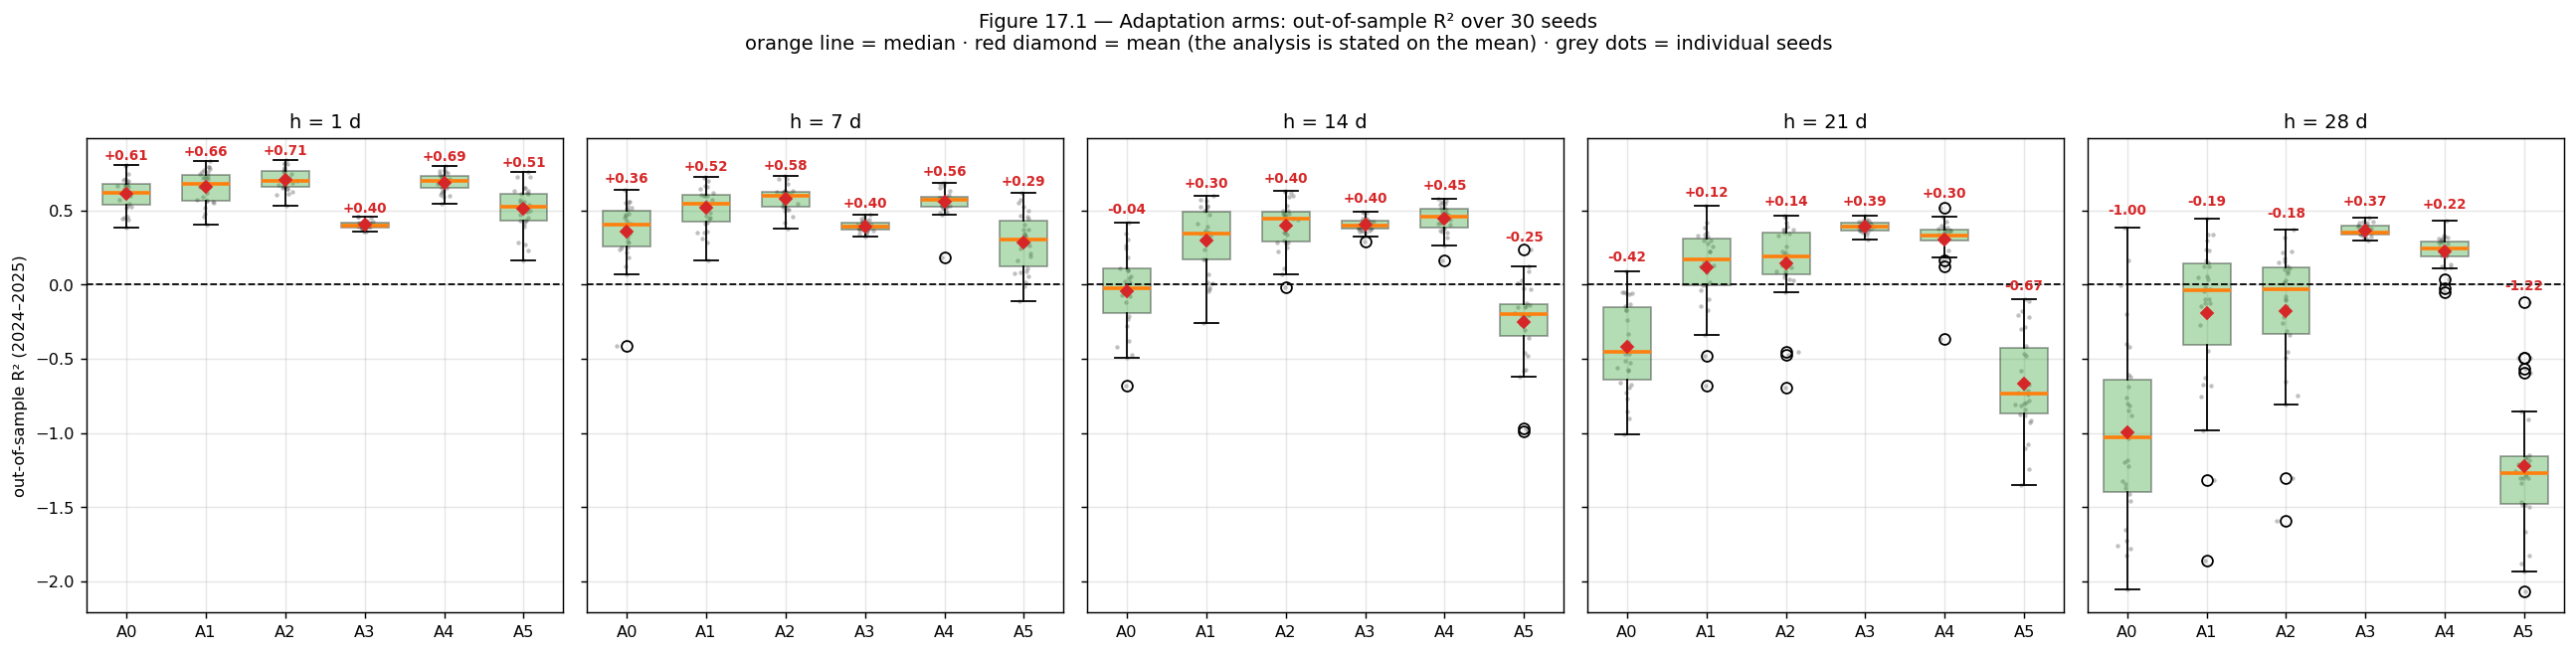

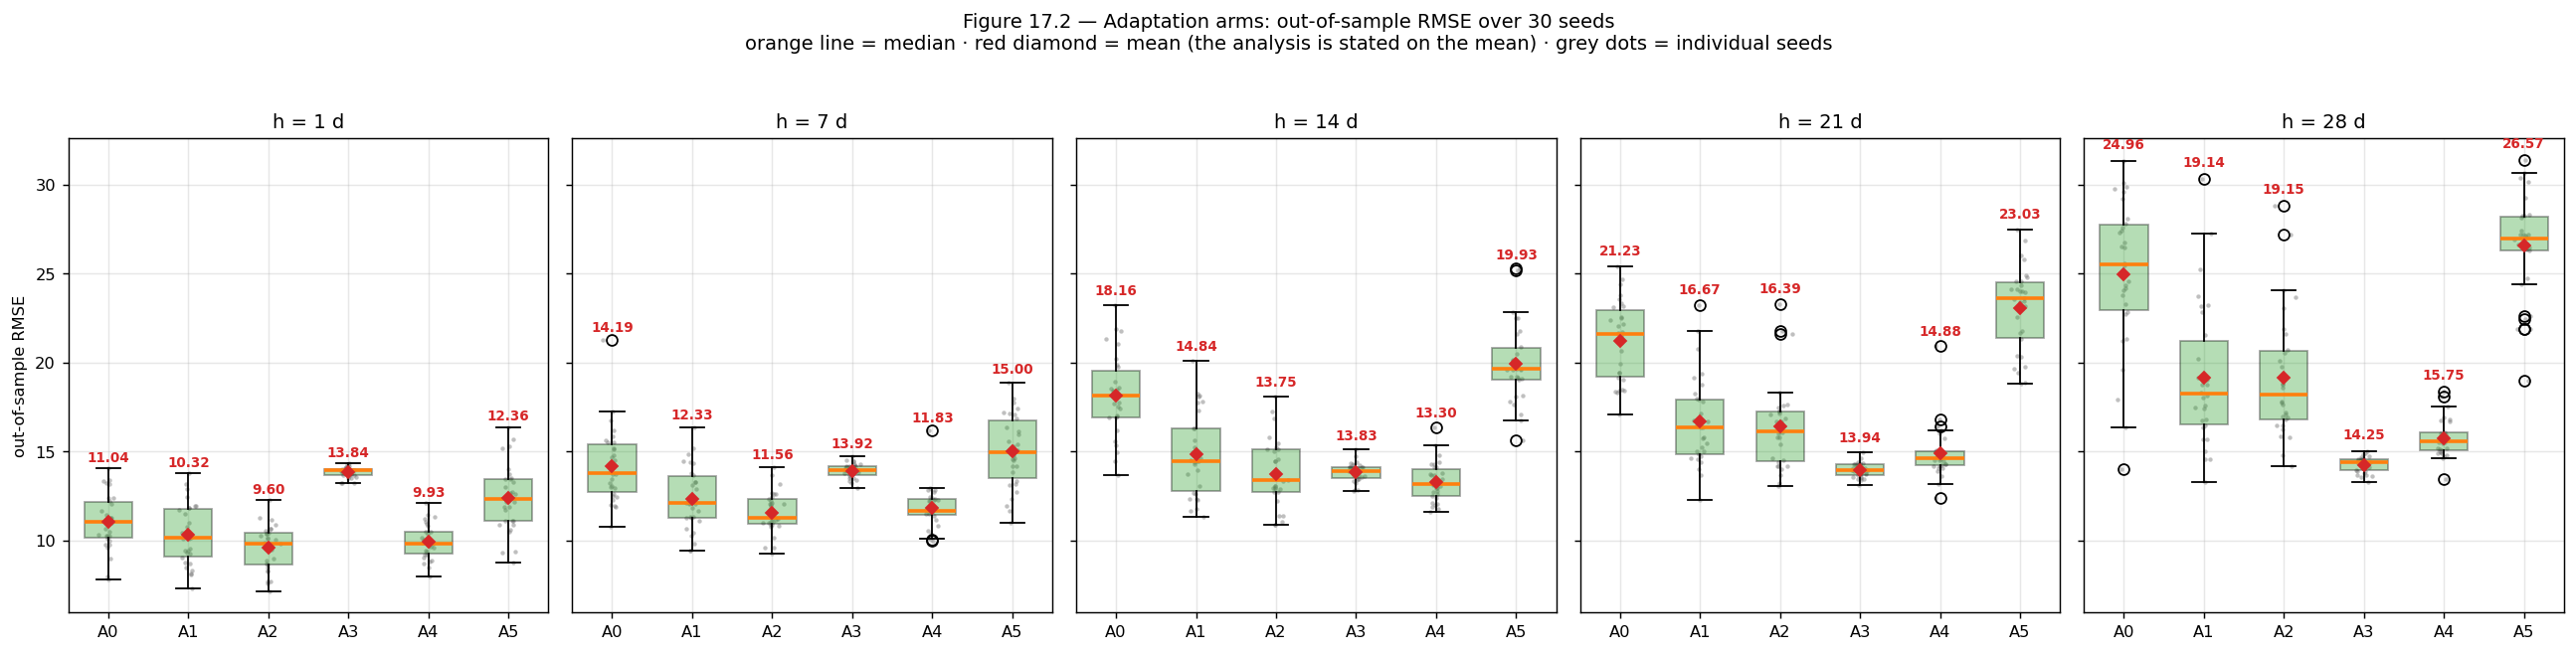

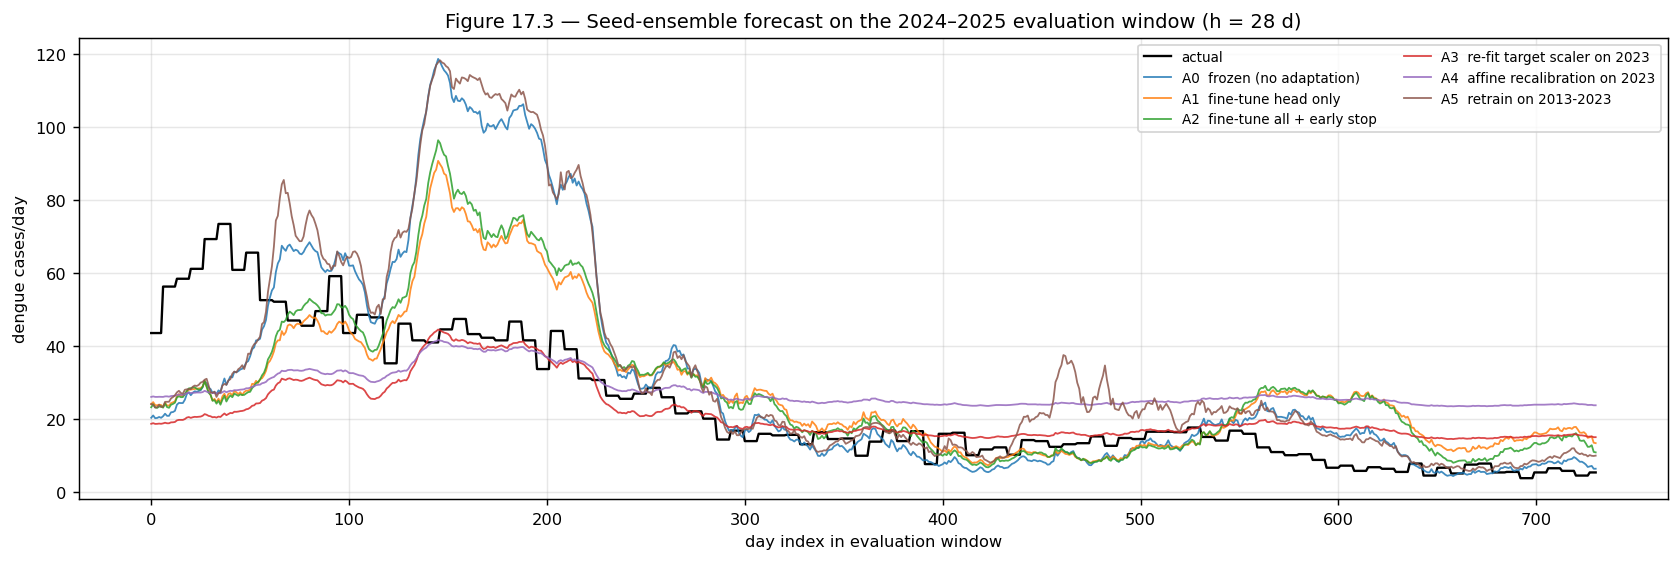

In [8]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4.0 * len(HORIZONS), 4.8), sharey=True)
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    data = [res[(res.horizon == h) & (res.arm == a)]['r2'].values for a in ARMS]
    boxplot_mean_median(ax, data, [a.split('_')[0] for a in ARMS],
                        ylabel='out-of-sample R² (2024–2025)' if h == HORIZONS[0] else '',
                        title=f'h = {h} d', fmt='{:+.2f}')
    ax.axhline(0, color='k', ls='--', lw=1)
fig.suptitle('Figure 17.1 — Adaptation arms: out-of-sample R² over 30 seeds\n' + LEGEND_NOTE, y=1.04)
fig.tight_layout(); fig.savefig('plots/nb17_arms_r2_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4.0 * len(HORIZONS), 4.8), sharey=True)
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    data = [res[(res.horizon == h) & (res.arm == a)]['rmse'].values for a in ARMS]
    boxplot_mean_median(ax, data, [a.split('_')[0] for a in ARMS],
                        ylabel='out-of-sample RMSE' if h == HORIZONS[0] else '',
                        title=f'h = {h} d')
fig.suptitle('Figure 17.2 — Adaptation arms: out-of-sample RMSE over 30 seeds\n' + LEGEND_NOTE, y=1.04)
fig.tight_layout(); fig.savefig('plots/nb17_arms_rmse_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

h_show = 28
fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(pred_store[h_show]['actual'], color='k', lw=1.3, label='actual')
for a in ARMS:
    ax.plot(pred_store[h_show][a], lw=1.0, alpha=0.85, label=ARM_LABEL[a])
ax.set_title(f'Figure 17.3 — Seed-ensemble forecast on the 2024–2025 evaluation window (h = {h_show} d)')
ax.set_xlabel('day index in evaluation window'); ax.set_ylabel('dengue cases/day')
ax.legend(fontsize=7.5, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('plots/nb17_arms_forecast_overlay.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Verdict to carry into the workbook

Paste the printed table below into the **H5** sheet of `FYP_Viva_Result.xlsx`, replacing the old
two-row "Arm A / Arm B" mitigation block.

The honest form of the conclusion — whichever way the numbers fall — is one of:

* *"Adaptation does work, but not by fine-tuning the weights: arm A**n** restores R² to … at h = …
  (p = …), which identifies the original failure as [mechanism] rather than as an intrinsic limit of
  the model."*
* *"No adaptation arm restores positive R² beyond h = … d. The error decomposition attributes this
  to [mechanism], not to a tuning choice, so the long-horizon limitation is reported as a genuine
  boundary of the approach and as the primary item for future work."*

Do not write the first sentence unless the table supports it.

In [9]:
best = (S.loc[S.groupby('horizon')['r2_mean'].idxmax()]
          [['horizon', 'label', 'r2_mean', 'r2_ci_lo', 'r2_ci_hi',
            'p_r2_gt_0_holm', 'decision_r2_gt_0', 'delta_r2_vs_A0', 'p_vs_A0_holm']])
print('BEST ARM PER HORIZON\n' + '=' * 120)
print(best.round(4).to_string(index=False))
best.to_csv('metrics/nb17_best_arm_per_horizon.csv', index=False)

print('\nOne-line summary for each horizon:')
for _, r in best.iterrows():
    verdict = ('positive out-of-sample skill RESTORED' if r.decision_r2_gt_0 == 'Reject H0'
               else 'still no positive out-of-sample skill')
    print(f'  {r.horizon:>6}: best = {r.label:<34} R2 = {r.r2_mean:+.3f} '
          f'[{r.r2_ci_lo:+.3f}, {r.r2_ci_hi:+.3f}]  ->  {verdict}')

BEST ARM PER HORIZON
horizon                            label  r2_mean  r2_ci_lo  r2_ci_hi  p_r2_gt_0_holm decision_r2_gt_0  delta_r2_vs_A0  p_vs_A0_holm
  h=14d A4  affine recalibration on 2023   0.4452    0.4097    0.4807             0.0        Reject H0          0.4894           0.0
   h=1d   A2  fine-tune all + early stop   0.7082    0.6805    0.7358             0.0        Reject H0          0.0957           0.0
  h=21d A3  re-fit target scaler on 2023   0.3935    0.3803    0.4067             0.0        Reject H0          0.8132           0.0
  h=28d A3  re-fit target scaler on 2023   0.3661    0.3518    0.3804             0.0        Reject H0          1.3617           0.0
   h=7d   A2  fine-tune all + early stop   0.5791    0.5480    0.6103             0.0        Reject H0          0.2200           0.0

One-line summary for each horizon:
   h=14d: best = A4  affine recalibration on 2023   R2 = +0.445 [+0.410, +0.481]  ->  positive out-of-sample skill RESTORED
    h=1d: best = A2  